# Semana 3 — Diagnóstico de Overfitting/Underfitting

**Proyecto:** Asistente de IA para Innovación, Desarrollo y Gestión del Conocimiento Técnico — DINDES

## Enfoque metodológico
El MVP del Asistente utiliza una arquitectura **RAG** y no contempla entrenar de extremo a extremo el LLM Qwen con los documentos institucionales. Para cumplir la actividad sin alterar la arquitectura, se analiza un **clasificador auxiliar de relevancia pregunta–documento**, representativo de retrieval/reranking.

### Controles metodológicos incorporados
1. Split por `qa_id` **antes** de cualquier aumentación.
2. Aumentación exclusivamente en training.
3. Métricas: Accuracy, Precision, Recall y F1.
4. Curvas básicas requeridas: Training vs Validation Loss y Accuracy.
5. Curvas avanzadas: `learning_curve` y `validation_curve` de Scikit-learn.
6. Visualizaciones guardadas a **300 DPI** con títulos, ejes, leyendas, grid y anotaciones.
7. Dos estrategias principales de mejora:
   - Balanceo de clases mediante `sample_weight`.
   - Feature Engineering de similitud pregunta–documento.
8. Early stopping como análisis complementario.

> Los datasets usados son **samples sintéticos** con fines académicos. Los resultados no representan desempeño operativo del Asistente DINDES.

## 1. Configuración, carga y validación de datos

In [30]:
from pathlib import Path
import copy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, learning_curve, validation_curve
from sklearn.metrics import (
    log_loss, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

SEED=42
np.random.seed(SEED)

# Detectar raíz del proyecto tanto si se ejecuta desde /notebooks como desde la raíz.
if Path('../data').exists():
    PROJECT_ROOT=Path('..')
elif Path('data').exists():
    PROJECT_ROOT=Path('.')
else:
    PROJECT_ROOT=Path('.')

DATA_DIR=PROJECT_ROOT/'data' if (PROJECT_ROOT/'data').exists() else PROJECT_ROOT
FIG_DIR=PROJECT_ROOT/'outputs'/'figures'
FIG_DIR.mkdir(parents=True,exist_ok=True)

def localizar(nombre):
    candidatos=[DATA_DIR/nombre,Path('../data')/nombre,Path('data')/nombre,Path('../')/nombre,Path(nombre)]
    for p in candidatos:
        if p.exists(): return p
    raise FileNotFoundError(f'No se encontró {nombre}. Revise la carpeta data/.')

def guardar_figura(nombre):
    ruta=FIG_DIR/nombre
    plt.tight_layout()
    plt.savefig(ruta,dpi=300,bbox_inches='tight')
    return ruta

DOCS_FILE=localizar('Dataset_1_Documentacion_Tecnica_DINDES_Sample.csv')
QA_FILE=localizar('Dataset_3_Evaluacion_QA_Asistente_IA_Sample.csv')
docs=pd.read_csv(DOCS_FILE)
qa=pd.read_csv(QA_FILE)

print('Documentos:',docs.shape,'->',DOCS_FILE)
print('QA:',qa.shape,'->',QA_FILE)
print('\nColumnas documentos:',docs.columns.tolist())
print('Columnas QA:',qa.columns.tolist())
print('Directorio de figuras:',FIG_DIR)

Documentos: (8, 12) -> ..\data\Dataset_1_Documentacion_Tecnica_DINDES_Sample.csv
QA: (10, 9) -> ..\data\Dataset_3_Evaluacion_QA_Asistente_IA_Sample.csv

Columnas documentos: ['document_id', 'project_id', 'document_type', 'title', 'responsible_unit', 'document_date', 'version', 'section', 'chunk_id', 'text', 'source_status', 'access_level']
Columnas QA: ['qa_id', 'question', 'category', 'expected_source_id', 'expected_answer', 'acceptable_answer', 'difficulty', 'answerable', 'notes']
Directorio de figuras: ..\outputs\figures


## 2. Construcción de pares pregunta–documento y EDA

In [31]:
answerable=qa[(qa['answerable'].astype(str).str.lower()=='si') & qa['expected_source_id'].notna()].copy()
answerable=answerable[answerable['expected_source_id'].astype(str).str.startswith('DOC-')]

pairs=[]
for _,q in answerable.iterrows():
    expected=str(q['expected_source_id']).split(';')[0]
    for _,d in docs.iterrows():
        pair_text=f"pregunta: {q['question']} documento: {d['title']} {d['section']} {d['text']}"
        pairs.append([q['qa_id'],pair_text,int(str(d['document_id'])==expected)])
pairs=pd.DataFrame(pairs,columns=['qa_id','pair_text','label'])

print('Pares originales:',pairs.shape)
print('\nDistribución de clases:')
print(pairs.label.value_counts())
print('\nDistribución porcentual:')
print((pairs.label.value_counts(normalize=True)*100).round(2))
print('\nPreguntas únicas:',pairs.qa_id.nunique())

Pares originales: (48, 3)

Distribución de clases:
label
0    42
1     6
Name: count, dtype: int64

Distribución porcentual:
label
0    87.5
1    12.5
Name: proportion, dtype: float64

Preguntas únicas: 6


## 3. Split por pregunta antes de la aumentación

La separación se realiza por `qa_id`: una pregunta completa pertenece exclusivamente a training o validation.

In [32]:
qa_ids=np.array(sorted(pairs.qa_id.unique()))
rng_split=np.random.default_rng(SEED)
qa_ids=rng_split.permutation(qa_ids)
n_val=max(2,int(round(len(qa_ids)*0.30)))
val_ids=set(qa_ids[:n_val]); train_ids=set(qa_ids[n_val:])

train_original=pairs[pairs.qa_id.isin(train_ids)].reset_index(drop=True)
val_data=pairs[pairs.qa_id.isin(val_ids)].reset_index(drop=True)
assert set(train_original.qa_id).isdisjoint(set(val_data.qa_id))

print('QA IDs training:',sorted(train_ids))
print('QA IDs validation:',sorted(val_ids))
print('\nTraining original:',train_original.shape)
print('Validation original:',val_data.shape)
print('\nTraining clases:\n',train_original.label.value_counts())
print('\nValidation clases:\n',val_data.label.value_counts())
print('\nIntersección qa_id:',set(train_original.qa_id)&set(val_data.qa_id))

QA IDs training: [np.str_('QA-001'), np.str_('QA-002'), np.str_('QA-005'), np.str_('QA-006')]
QA IDs validation: [np.str_('QA-003'), np.str_('QA-004')]

Training original: (32, 3)
Validation original: (16, 3)

Training clases:
 label
0    28
1     4
Name: count, dtype: int64

Validation clases:
 label
0    14
1     2
Name: count, dtype: int64

Intersección qa_id: set()


## 4. Aumentación controlada solo de training y vectorización

In [33]:
def generar_variantes(texto,n_variantes=5):
    reemplazos=[('¿',''),('?',''),(' de ',' del '),('Qué ','Que '),('sistema','solución')]
    variantes=[]
    for i in range(n_variantes):
        a,b=reemplazos[i%len(reemplazos)]
        variantes.append(texto.replace(a,b,1))
    return variantes

aug=[]
for _,row in train_original.iterrows():
    aug.append(row.to_dict())
    for v in generar_variantes(row.pair_text,5):
        aug.append({'qa_id':row.qa_id,'pair_text':v,'label':row.label})
train_data=pd.DataFrame(aug)

X_train_text=train_data.pair_text; y_train=train_data.label.astype(int)
X_val_text=val_data.pair_text; y_val=val_data.label.astype(int)
vectorizer=TfidfVectorizer(ngram_range=(1,2),min_df=1,max_features=2500)
X_train=vectorizer.fit_transform(X_train_text); X_val=vectorizer.transform(X_val_text)

print('Training aumentado:',train_data.shape)
print('Validation SIN aumentar:',val_data.shape)
print('Vocabulario TF-IDF:',len(vectorizer.vocabulary_))

Training aumentado: (192, 3)
Validation SIN aumentar: (16, 3)
Vocabulario TF-IDF: 340


## 5. Sistema de tracking reproducible

In [34]:
def entrenar_sgd(alpha=1e-7,epochs=50,balanced=False,seed=SEED):
    model=SGDClassifier(loss='log_loss',penalty='l2',alpha=alpha,random_state=seed)
    classes=np.array([0,1]); rng=np.random.default_rng(seed); y_arr=y_train.to_numpy()
    sample_weights=np.ones(len(y_arr),dtype=float)
    if balanced:
        weights=compute_class_weight(class_weight='balanced',classes=classes,y=y_arr)
        weight_dict=dict(zip(classes,weights)); sample_weights=np.array([weight_dict[v] for v in y_arr])
    else:
        weight_dict={0:1.0,1:1.0}
    history=[]; snapshots=[]
    for epoch in range(1,epochs+1):
        idx=rng.permutation(X_train.shape[0])
        model.partial_fit(X_train[idx],y_arr[idx],classes=classes,sample_weight=sample_weights[idx])
        p_tr=model.predict_proba(X_train); p_va=model.predict_proba(X_val)
        yhat_tr=model.predict(X_train); yhat_va=model.predict(X_val)
        history.append({
            'epoch':epoch,
            'train_loss':log_loss(y_train,p_tr,labels=[0,1]),
            'val_loss':log_loss(y_val,p_va,labels=[0,1]),
            'train_acc':accuracy_score(y_train,yhat_tr),
            'val_acc':accuracy_score(y_val,yhat_va),
            'val_precision':precision_score(y_val,yhat_va,zero_division=0),
            'val_recall':recall_score(y_val,yhat_va,zero_division=0),
            'val_f1':f1_score(y_val,yhat_va,zero_division=0)
        })
        snapshots.append(copy.deepcopy(model))
    return model,pd.DataFrame(history),snapshots,weight_dict

## 6. Modelo base con logging

In [35]:
base_model,hist_base,snaps_base,_=entrenar_sgd(alpha=1e-7,epochs=50,balanced=False)
idx_loss_base=hist_base.val_loss.idxmin(); best_loss_base=hist_base.loc[idx_loss_base]
print('Mejor época por Validation Loss:',int(best_loss_base.epoch))
print(hist_base.tail())

Mejor época por Validation Loss: 32
    epoch  train_loss   val_loss  train_acc  val_acc  val_precision  \
45     46    4.206714   7.260684   0.755208    0.750            0.0   
46     47    3.040829   4.505953   0.875000    0.875            0.0   
47     48    3.338270   6.528057   0.776042    0.625            0.0   
48     49    4.699420   6.920769   0.812500    0.750            0.0   
49     50    6.373460  11.295455   0.729167    0.625            0.0   

    val_recall  val_f1  
45         0.0     0.0  
46         0.0     0.0  
47         0.0     0.0  
48         0.0     0.0  
49         0.0     0.0  


### 6.1 Curvas básicas requeridas — 300 DPI

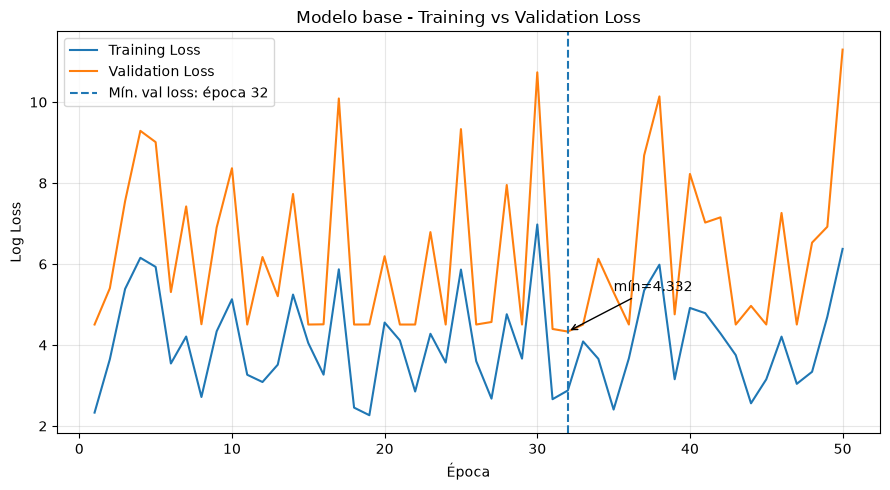

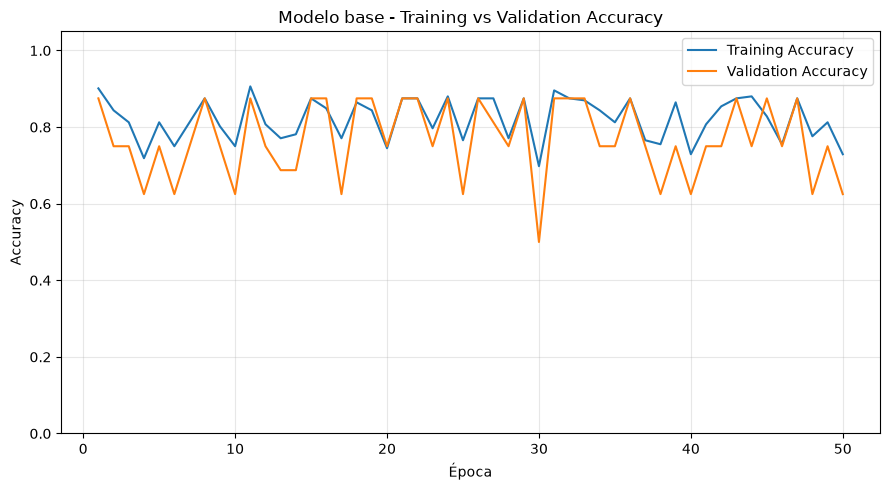

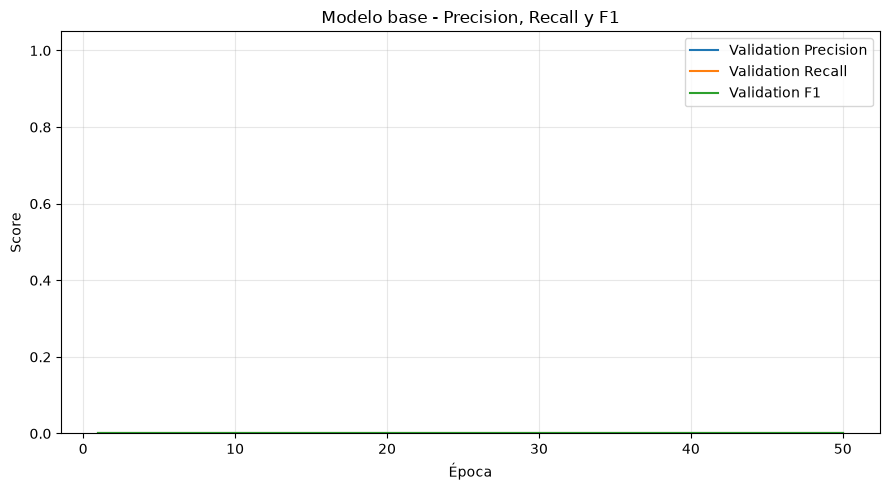

In [36]:
# A. Training vs Validation Loss
plt.figure(figsize=(9,5))
plt.plot(hist_base.epoch,hist_base.train_loss,label='Training Loss')
plt.plot(hist_base.epoch,hist_base.val_loss,label='Validation Loss')
plt.axvline(best_loss_base.epoch,linestyle='--',label=f"Mín. val loss: época {int(best_loss_base.epoch)}")
plt.annotate(f"mín={best_loss_base.val_loss:.3f}",xy=(best_loss_base.epoch,best_loss_base.val_loss),
             xytext=(best_loss_base.epoch+3,best_loss_base.val_loss+1),arrowprops={'arrowstyle':'->'})
plt.xlabel('Época'); plt.ylabel('Log Loss'); plt.title('Modelo base - Training vs Validation Loss')
plt.grid(alpha=.3); plt.legend(); guardar_figura('01_training_validation_loss.png'); plt.show()

# B. Training vs Validation Accuracy
plt.figure(figsize=(9,5))
plt.plot(hist_base.epoch,hist_base.train_acc,label='Training Accuracy')
plt.plot(hist_base.epoch,hist_base.val_acc,label='Validation Accuracy')
plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.title('Modelo base - Training vs Validation Accuracy')
plt.ylim(0,1.05); plt.grid(alpha=.3); plt.legend(); guardar_figura('02_training_validation_accuracy.png'); plt.show()

# Métricas adicionales de la clase relevante
plt.figure(figsize=(9,5))
plt.plot(hist_base.epoch,hist_base.val_precision,label='Validation Precision')
plt.plot(hist_base.epoch,hist_base.val_recall,label='Validation Recall')
plt.plot(hist_base.epoch,hist_base.val_f1,label='Validation F1')
plt.xlabel('Época'); plt.ylabel('Score'); plt.title('Modelo base - Precision, Recall y F1')
plt.ylim(0,1.05); plt.grid(alpha=.3); plt.legend(); guardar_figura('03_precision_recall_f1_base.png'); plt.show()

### Diagnóstico del modelo base
La accuracy aislada es engañosa por el desbalance. Si `Precision/Recall/F1=0`, el modelo no identifica documentos relevantes aunque la accuracy sea alta. Las curvas deben evaluarse buscando los patrones descritos en la actividad: separación creciente train/validation para overfitting; rendimiento bajo en ambos para underfitting; convergencia estable para comportamiento óptimo.

## 7. Mejora 1 — balanceo de clases

In [37]:
balanced_model,hist_bal,snaps_bal,class_weights=entrenar_sgd(alpha=1e-3,epochs=50,balanced=True)
idx_f1_bal=hist_bal.val_f1.idxmax(); best_f1_bal=hist_bal.loc[idx_f1_bal]
print('Pesos de clase:',class_weights)
print('\nMejor época balanceada por F1:')
print(best_f1_bal.to_string())

Pesos de clase: {np.int64(0): np.float64(0.5714285714285714), np.int64(1): np.float64(4.0)}

Mejor época balanceada por F1:
epoch            1.000000
train_loss       0.805194
val_loss         1.167197
train_acc        0.656250
val_acc          0.500000
val_precision    0.000000
val_recall       0.000000
val_f1           0.000000


## 8. Mejora 2 — Feature Engineering de similitud pregunta–documento

In [38]:
def construir_pares_detallados(ids):
    registros=[]
    subset_qa=answerable[answerable.qa_id.isin(ids)]
    for _,q in subset_qa.iterrows():
        expected=str(q.expected_source_id).split(';')[0]
        for _,d in docs.iterrows():
            documento=f"{d['title']} {d['section']} {d['text']}"
            registros.append({'qa_id':q.qa_id,'question':q.question,'document_id':d.document_id,
                              'document_text':documento,'label':int(str(d.document_id)==expected)})
    return pd.DataFrame(registros)

train_pairs_fe=construir_pares_detallados(train_ids); val_pairs_fe=construir_pares_detallados(val_ids)
print('Training pares:',train_pairs_fe.shape)
print('Validation pares:',val_pairs_fe.shape)

Training pares: (32, 5)
Validation pares: (16, 5)


In [39]:
def tokenizar(texto):
    return set(re.findall(r"\b[a-záéíóúñ0-9\-\.]+\b",str(texto).lower()))
def overlap_ratio(q,d):
    tq=tokenizar(q); td=tokenizar(d); return len(tq&td)/len(tq) if tq else 0.0
def length_ratio(q,d):
    lq=len(str(q)); ld=len(str(d)); return min(lq,ld)/max(lq,ld) if max(lq,ld)>0 else 0.0
def technical_overlap(q,d):
    tq=tokenizar(q); td=tokenizar(d); tech={t for t in tq if any(c.isdigit() for c in t) or '-' in t}
    return len(tech&td)/len(tech) if tech else 0.0

tfidf_fe=TfidfVectorizer(ngram_range=(1,2),min_df=1)
tfidf_fe.fit(pd.concat([train_pairs_fe.question,train_pairs_fe.document_text]).astype(str))
def cosine_feature(q,d):
    v=tfidf_fe.transform([q,d]); return cosine_similarity(v[0],v[1])[0,0]
def crear_features(df):
    return pd.DataFrame([{
        'cosine_similarity':cosine_feature(r.question,r.document_text),
        'overlap_ratio':overlap_ratio(r.question,r.document_text),
        'length_ratio':length_ratio(r.question,r.document_text),
        'technical_overlap':technical_overlap(r.question,r.document_text)} for _,r in df.iterrows()])

X_train_fe=crear_features(train_pairs_fe); X_val_fe=crear_features(val_pairs_fe)
y_train_fe=train_pairs_fe.label.astype(int); y_val_fe=val_pairs_fe.label.astype(int)
print('Features training:'); display(X_train_fe.head())
print('\nEstadísticas:'); display(X_train_fe.describe())

Features training:


,cosine_similarity,overlap_ratio,length_ratio,technical_overlap
0,0.275910,0.6,0.425000,0.0
1,0.031038,0.1,0.442708,0.0
2,0.000000,0.0,0.408654,0.0
3,0.035225,0.1,0.452128,0.0
4,0.041679,0.3,0.389908,0.0



Estadísticas:


,cosine_similarity,overlap_ratio,length_ratio,technical_overlap
count,32.000000,32.000000,32.000000,32.0
mean,0.047732,0.196749,0.410844,0.0
std,0.078982,0.178049,0.059312,0.0
min,0.000000,0.000000,0.311927,0.0
25%,0.011257,0.100000,0.361277,0.0
50%,0.024924,0.181818,0.408654,0.0
75%,0.042327,0.279545,0.445026,0.0
max,0.373362,0.800000,0.541401,0.0


> Si `technical_overlap` presenta media, desviación y máximo iguales a cero, esta feature no aporta información en este sample. En un corpus institucional real podría ser útil para códigos, modelos y números de parte.

In [40]:
scaler=StandardScaler(); X_train_scaled=scaler.fit_transform(X_train_fe); X_val_scaled=scaler.transform(X_val_fe)
modelo_features=LogisticRegression(class_weight='balanced',random_state=SEED,max_iter=1000)
modelo_features.fit(X_train_scaled,y_train_fe)
pred_features=modelo_features.predict(X_val_scaled)
feature_metrics={
    'accuracy':accuracy_score(y_val_fe,pred_features),
    'precision':precision_score(y_val_fe,pred_features,zero_division=0),
    'recall':recall_score(y_val_fe,pred_features,zero_division=0),
    'f1':f1_score(y_val_fe,pred_features,zero_division=0)}
print('=== MODELO CON FEATURE ENGINEERING ===')
for k,v in feature_metrics.items(): print(f'{k.capitalize()}: {v:.4f}')

=== MODELO CON FEATURE ENGINEERING ===
Accuracy: 0.8125
Precision: 0.4000
Recall: 1.0000
F1: 0.5714


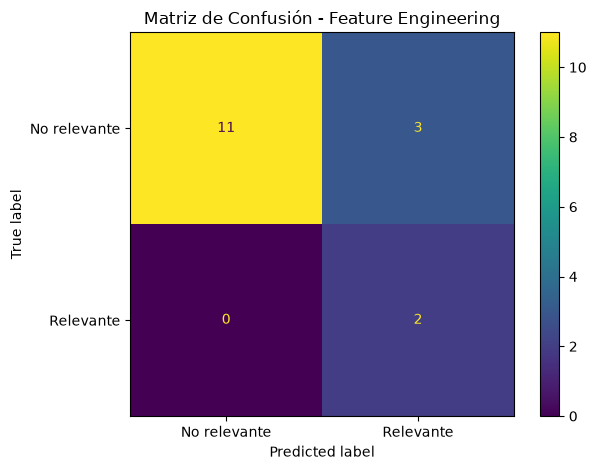

In [41]:
cm_features=confusion_matrix(y_val_fe,pred_features)
ConfusionMatrixDisplay(cm_features,display_labels=['No relevante','Relevante']).plot()
plt.title('Matriz de Confusión - Feature Engineering')
guardar_figura('04_confusion_feature_engineering.png'); plt.show()

## 9. Curvas avanzadas de Scikit-learn — puntos extra

Para cumplir explícitamente la recomendación de Scikit-learn de la actividad, se incorporan `learning_curve` y `validation_curve`. Se utiliza `GroupKFold` con `qa_id` como grupo para impedir que una misma pregunta quede simultáneamente en train y validation durante cross-validation.

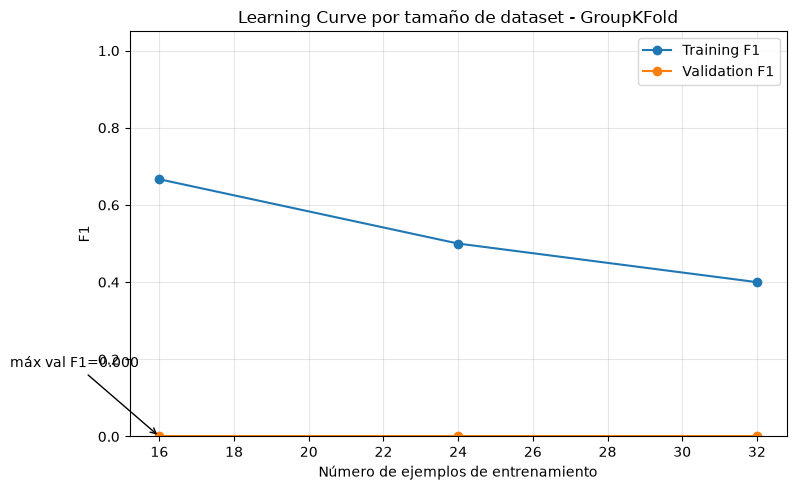

,train_size,train_f1,validation_f1
0,16,0.666667,0.0
1,24,0.500000,0.0
2,32,0.400000,0.0


In [42]:
# Pipeline para curvas avanzadas sobre pares ORIGINALES, sin aumentación.
pipe_cv=Pipeline([
    ('tfidf',TfidfVectorizer(ngram_range=(1,2),min_df=1,max_features=2500)),
    ('clf',SGDClassifier(loss='log_loss',penalty='l2',alpha=1e-3,random_state=SEED,max_iter=2000,tol=1e-3,class_weight='balanced'))
])

groups=pairs.qa_id.to_numpy()
cv=GroupKFold(n_splits=3)

train_sizes,train_scores,val_scores=learning_curve(
    pipe_cv,pairs.pair_text,pairs.label,
    groups=groups,cv=cv,scoring='f1',
    train_sizes=np.array([0.50,0.75,1.00]),
    shuffle=False,n_jobs=1,error_score=np.nan
)

train_mean=np.nanmean(train_scores,axis=1); val_mean=np.nanmean(val_scores,axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes,train_mean,marker='o',label='Training F1')
plt.plot(train_sizes,val_mean,marker='o',label='Validation F1')
best_i=int(np.nanargmax(val_mean))
plt.annotate(f"máx val F1={val_mean[best_i]:.3f}",xy=(train_sizes[best_i],val_mean[best_i]),
             xytext=(train_sizes[best_i]*0.75,min(1.0,val_mean[best_i]+0.18)),arrowprops={'arrowstyle':'->'})
plt.xlabel('Número de ejemplos de entrenamiento'); plt.ylabel('F1')
plt.title('Learning Curve por tamaño de dataset - GroupKFold')
plt.ylim(0,1.05); plt.grid(alpha=.3); plt.legend(); guardar_figura('05_learning_curve_dataset_size.png'); plt.show()

pd.DataFrame({'train_size':train_sizes,'train_f1':train_mean,'validation_f1':val_mean})

### Interpretación de la Learning Curve

La curva de aprendizaje muestra que el F1 de validación permanece en 0 para los diferentes tamaños de entrenamiento evaluados, mientras que el F1 de entrenamiento disminuye a medida que aumenta el número de ejemplos. Esto indica que incrementar únicamente la cantidad de pares disponibles dentro de este pequeño conjunto no permite al modelo base generalizar hacia preguntas no observadas.

El resultado refuerza la hipótesis de que la principal limitación no se encuentra únicamente en la cantidad de datos, sino también en la forma en que se representa la relación entre pregunta y documento.

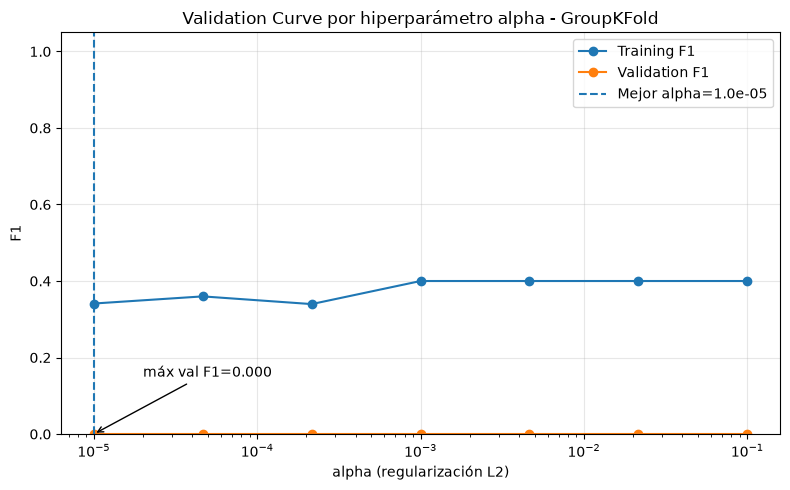

,alpha,train_f1,validation_f1
0,0.000010,0.341161,0.0
1,0.000046,0.359809,0.0
2,0.000215,0.339683,0.0
3,0.001000,0.400000,0.0
4,0.004642,0.400000,0.0
5,0.021544,0.400000,0.0
6,0.100000,0.400000,0.0


In [43]:
alphas=np.logspace(-5,-1,7)
tr_alpha,val_alpha=validation_curve(
    pipe_cv,pairs.pair_text,pairs.label,
    param_name='clf__alpha',param_range=alphas,
    groups=groups,cv=cv,scoring='f1',n_jobs=1,error_score=np.nan
)
tr_alpha_mean=np.nanmean(tr_alpha,axis=1); val_alpha_mean=np.nanmean(val_alpha,axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(alphas,tr_alpha_mean,marker='o',label='Training F1')
plt.semilogx(alphas,val_alpha_mean,marker='o',label='Validation F1')
best_a=int(np.nanargmax(val_alpha_mean))
plt.axvline(alphas[best_a],linestyle='--',label=f'Mejor alpha={alphas[best_a]:.1e}')
plt.annotate(f"máx val F1={val_alpha_mean[best_a]:.3f}",xy=(alphas[best_a],val_alpha_mean[best_a]),
             xytext=(alphas[best_a]*2,min(1.0,val_alpha_mean[best_a]+0.15)),arrowprops={'arrowstyle':'->'})
plt.xlabel('alpha (regularización L2)'); plt.ylabel('F1')
plt.title('Validation Curve por hiperparámetro alpha - GroupKFold')
plt.ylim(0,1.05); plt.grid(alpha=.3); plt.legend(); guardar_figura('06_validation_curve_alpha.png'); plt.show()

pd.DataFrame({'alpha':alphas,'train_f1':tr_alpha_mean,'validation_f1':val_alpha_mean})

### Interpretación de la Validation Curve

La variación del hiperparámetro `alpha`, asociado a la regularización L2 del modelo, no produjo mejoras en el F1 de validación, que permaneció en 0 para todos los valores evaluados.

Esto indica que modificar exclusivamente la intensidad de regularización no corrige la incapacidad del modelo base para identificar la clase relevante. Por tanto, el problema no puede atribuirse únicamente a un nivel inadecuado de regularización y requiere una mejora en la representación de las características, lo cual justifica la estrategia de Feature Engineering.

## 10. Early Stopping — análisis complementario

In [44]:
idx_es=hist_bal.val_loss.idxmin(); early_row=hist_bal.loc[idx_es]
print('=== EARLY STOPPING SOBRE MODELO BALANCEADO ===')
print(early_row.to_string())

=== EARLY STOPPING SOBRE MODELO BALANCEADO ===
epoch            11.000000
train_loss        0.450870
val_loss          0.771507
train_acc         0.656250
val_acc           0.625000
val_precision     0.000000
val_recall        0.000000
val_f1            0.000000


## 11. Comparación antes/después de mejoras

In [45]:
base_best=snaps_base[idx_loss_base]; bal_best=snaps_bal[idx_f1_bal]
rows=[]
for name,model,ytrue,Xeval in [
    ('Modelo base',base_best,y_val,X_val),
    ('Balanceo de clases',bal_best,y_val,X_val)]:
    pred=model.predict(Xeval)
    rows.append({'modelo':name,'accuracy':accuracy_score(ytrue,pred),
                 'precision':precision_score(ytrue,pred,zero_division=0),
                 'recall':recall_score(ytrue,pred,zero_division=0),
                 'f1':f1_score(ytrue,pred,zero_division=0)})
rows.append({'modelo':'Feature Engineering',**feature_metrics})
comparacion=pd.DataFrame(rows)
comparacion

,modelo,accuracy,precision,recall,f1
0,Modelo base,0.8750,0.0,0.0,0.000000
1,Balanceo de clases,0.5000,0.0,0.0,0.000000
2,Feature Engineering,0.8125,0.4,1.0,0.571429


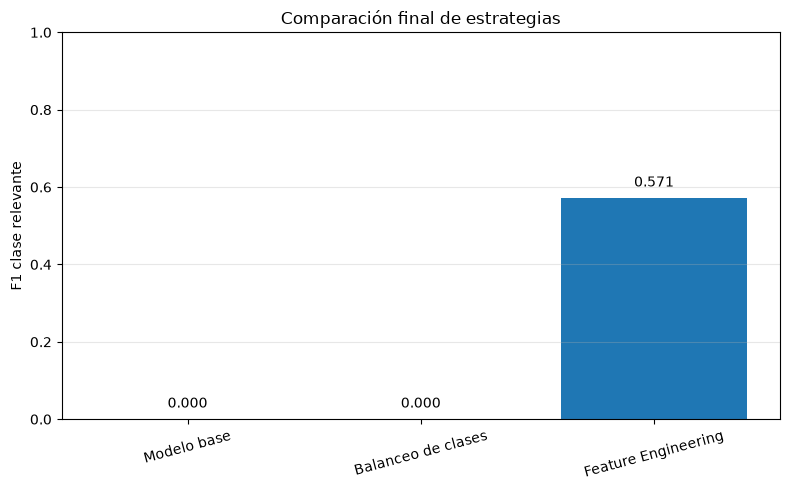

In [46]:
plt.figure(figsize=(8,5))
plt.bar(comparacion.modelo,comparacion.f1)
plt.ylabel('F1 clase relevante'); plt.title('Comparación final de estrategias')
plt.ylim(0,1.0); plt.grid(axis='y',alpha=.3); plt.xticks(rotation=15)
for i,v in enumerate(comparacion.f1):
    plt.text(i,v+0.03,f'{v:.3f}',ha='center')
guardar_figura('07_comparacion_estrategias_f1.png'); plt.show()

## 12. Diagnóstico sistemático — evidencia, estrategia y resultado

In [47]:
diagnostico_resumen=pd.DataFrame([
    {
        'Hallazgo':'Accuracy alta del modelo base, pero F1=0',
        'Evidencia':'Precision/Recall/F1 de validation permanecen en 0',
        'Diagnóstico':'Sesgo hacia clase mayoritaria + representación insuficiente; no overfitting clásico',
        'Estrategia':'Balanceo de clases',
        'Resultado':'No mejora F1 en este sample'
    },
    {
        'Hallazgo':'Balanceo no recupera positivos',
        'Evidencia':'F1 balanceado=0',
        'Diagnóstico':'El problema no es solo el desbalance',
        'Estrategia':'Feature Engineering',
        'Resultado':f"Accuracy={feature_metrics['accuracy']:.4f}; Precision={feature_metrics['precision']:.4f}; Recall={feature_metrics['recall']:.4f}; F1={feature_metrics['f1']:.4f}"
    },
    {
        'Hallazgo':'Validation muy pequeña',
        'Evidencia':'Solo 2 positivos en validation',
        'Diagnóstico':'Alta incertidumbre estadística',
        'Estrategia':'Split por qa_id + futura ampliación QA',
        'Resultado':'Sin leakage; métricas no extrapolables a producción'
    }
])
diagnostico_resumen

,Hallazgo,Evidencia,Diagnóstico,Estrategia,Resultado
0,"Accuracy alta del modelo base, pero F1=0",Precision/Recall/F1 de validation permanecen en 0,Sesgo hacia clase mayoritaria + representación...,Balanceo de clases,No mejora F1 en este sample
1,Balanceo no recupera positivos,F1 balanceado=0,El problema no es solo el desbalance,Feature Engineering,Accuracy=0.8125; Precision=0.4000; Recall=1.00...
2,Validation muy pequeña,Solo 2 positivos en validation,Alta incertidumbre estadística,Split por qa_id + futura ampliación QA,Sin leakage; métricas no extrapolables a produ...


## 13. Diagnóstico final y conclusiones

- El **modelo base** alcanzó valores de accuracy aparentemente aceptables; sin embargo, no identificó correctamente la clase relevante, obteniendo `Precision = 0`, `Recall = 0` y `F1 = 0` en el conjunto de validación. Esto demuestra que la accuracy, por sí sola, no es suficiente para evaluar el desempeño en un problema con clases desbalanceadas.

- La primera estrategia de mejora, **balanceo de clases**, corrigió la diferencia de ponderación entre ejemplos relevantes y no relevantes, pero no fue suficiente para que el modelo aprendiera una frontera de decisión útil, ya que las métricas de la clase relevante permanecieron en cero.

- La segunda estrategia, **Feature Engineering**, incorporó características explícitas de similitud entre pregunta y documento, permitiendo representar de forma más directa la relación de relevancia. Esta estrategia produjo la mejora más significativa del experimento.

- El modelo con Feature Engineering alcanzó **Accuracy = 0,8125, Precision = 0,40, Recall = 1,00 y F1 = 0,5714**. La matriz de confusión fue `TN = 11`, `FP = 3`, `FN = 0` y `TP = 2`.

- El valor de `Recall = 1,00` debe interpretarse con cautela, ya que el conjunto de validación contiene únicamente **dos ejemplos positivos**. Por tanto, significa que el modelo identificó correctamente 2 de 2 documentos relevantes, pero no constituye evidencia suficiente para extrapolar el desempeño a un entorno operacional.

- La característica `technical_overlap` presentó valor constante igual a cero en el conjunto de muestra, por lo que no aportó capacidad discriminativa en este experimento. En un corpus institucional real, con códigos de equipos, modelos, números de parte y nomenclatura técnica, esta característica podría resultar más relevante.

- Las curvas no muestran un patrón clásico de **overfitting**. Los resultados apuntan principalmente a **desbalance de clases, alta variabilidad por el reducido tamaño de la muestra y representación insuficiente de la relación pregunta–documento** en el modelo auxiliar inicial.

- La principal corrección metodológica fue realizar el **split por `qa_id` antes de la aumentación de datos** y aplicar la aumentación exclusivamente sobre training, evitando *data leakage*.

- Para el RAG real, debe evitarse ajustar repetidamente **chunking, Top-K, pesos dense/BM25 o reranking** sobre el mismo QA set utilizado para reportar métricas finales. Se recomienda separar desarrollo/validación y un conjunto independiente de prueba final.

## 14. Referencias técnicas

1. Scikit-learn — `SGDClassifier`, `LogisticRegression`, `learning_curve`, `validation_curve` y métricas de clasificación.
2. Scikit-learn — `GroupKFold` para validación respetando grupos `qa_id`.
3. Scikit-learn — `compute_class_weight`, `TfidfVectorizer` y `cosine_similarity`.
4. Actividad Semana 3 — Diagnóstico de Overfitting/Underfitting.
5. Dataset sample de Documentación Técnica DINDES y Dataset sample de Evaluación QA.